<a href="https://colab.research.google.com/github/Janmeshree/DAV-PRACS/blob/main/DAV_MULTIPLE_LINEAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Import required libraries for data handling and ML
from sklearn.datasets import fetch_california_housing  # dataset loader
import pandas as pd  # data manipulation
import numpy as np   # numerical computations

In [2]:
# Load California Housing dataset
housing = fetch_california_housing()

In [3]:
# Convert dataset into a pandas DataFrame
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column (house prices)
housing_df['MedHouseValue'] = housing.target

In [4]:
# Display first 5 rows of dataset
print(housing_df.head())

# Check for missing values in each column
print(housing_df.isnull().sum())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  
MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64


In [5]:
# Compute correlation between variables
correlation_matrix = housing_df.corr()

# Show correlation with target variable
print(correlation_matrix['MedHouseValue'])

MedInc           0.688075
HouseAge         0.105623
AveRooms         0.151948
AveBedrms       -0.046701
Population      -0.024650
AveOccup        -0.023737
Latitude        -0.144160
Longitude       -0.045967
MedHouseValue    1.000000
Name: MedHouseValue, dtype: float64


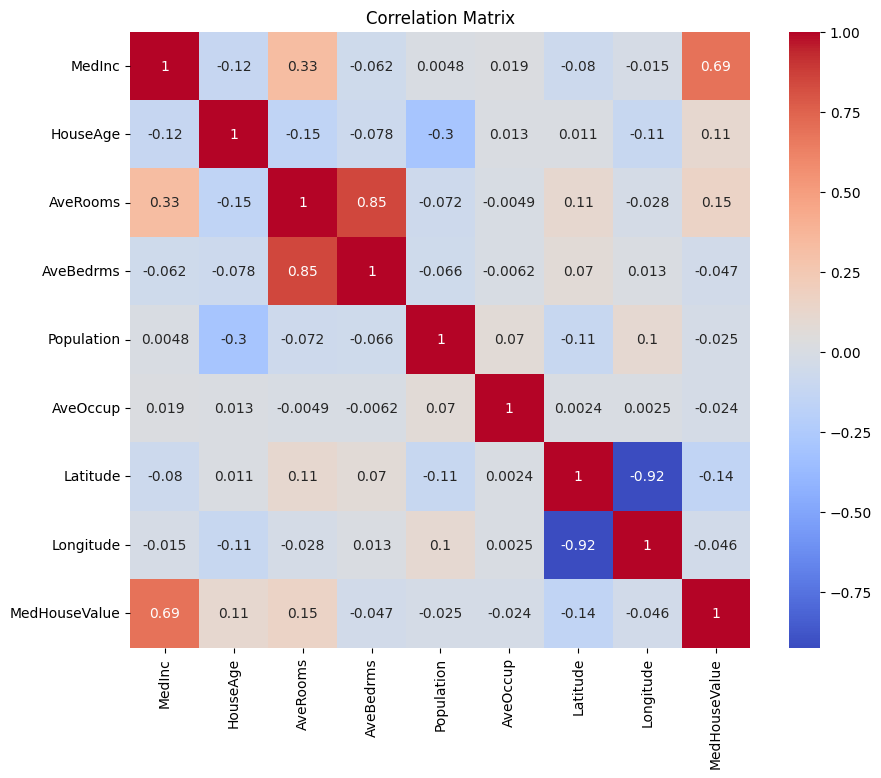

In [7]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(housing_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [8]:
# Select important features for regression
selected_features = ['MedInc', 'AveRooms', 'AveOccup']

# Independent variables (input features)
X = housing_df[selected_features]

# Dependent variable (target)
y = housing_df['MedHouseValue']

In [9]:
# Standardize features to improve model performance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform data
X_scaled = scaler.fit_transform(X)

# Display scaled data
print(X_scaled)

[[ 2.34476576  0.62855945 -0.04959654]
 [ 2.33223796  0.32704136 -0.09251223]
 [ 1.7826994   1.15562047 -0.02584253]
 ...
 [-1.14259331 -0.09031802 -0.0717345 ]
 [-1.05458292 -0.04021111 -0.09122515]
 [-0.78012947 -0.07044252 -0.04368215]]


In [10]:
# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [11]:
# Import and create Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Train model on training data
model.fit(X_train, y_train)

LinearRegression()

In [12]:
# Predict house prices for test data
y_pred = model.predict(X_test)

In [13]:
# Import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Calculate error and accuracy
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))

Mean Squared Error: 0.7006855912225249
R-squared: 0.4652924370503557


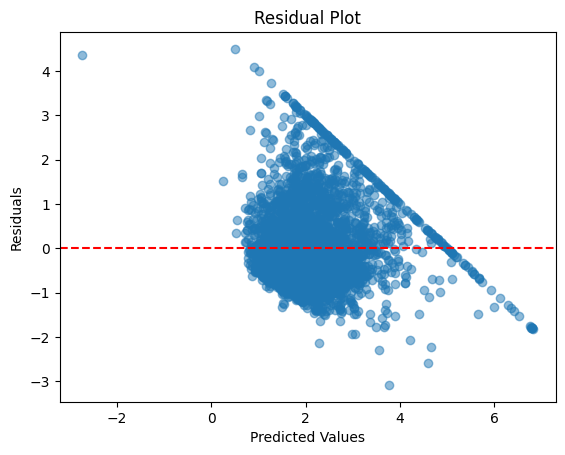

In [14]:
# Calculate residuals (errors)
residuals = y_test - y_pred

# Plot residuals to check error distribution
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

# Horizontal line at 0 error
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

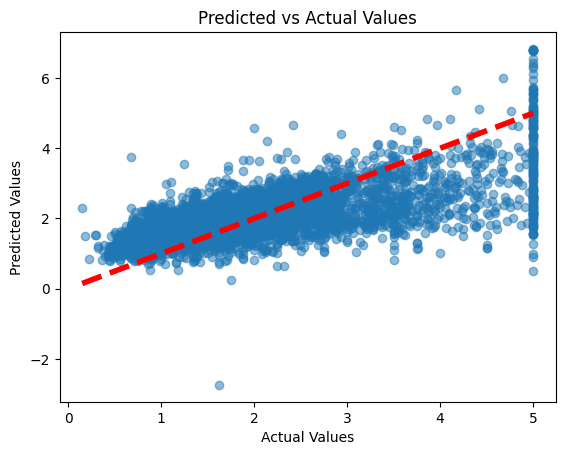

In [15]:
# Compare actual and predicted values
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')

# Ideal line (perfect prediction line)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=4)

plt.show()

In [16]:
# Statistical analysis of regression model
import statsmodels.api as sm

# Add constant term for intercept
X_train_sm = sm.add_constant(X_train)

# Fit Ordinary Least Squares (OLS) model
model_sm = sm.OLS(y_train, X_train_sm).fit()

# Print detailed statistical summary
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:          MedHouseValue   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     5173.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:13:06   Log-Likelihood:                -20354.
No. Observations:               16512   AIC:                         4.072e+04
Df Residuals:                   16508   BIC:                         4.075e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0679      0.006    320.074      0.0

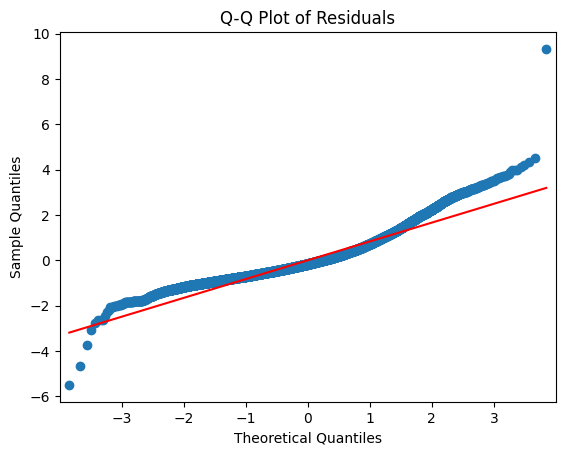

In [17]:
# Check if residuals follow normal distribution
sm.qqplot(model_sm.resid, line='s')

plt.title('Q-Q Plot of Residuals')
plt.show()